In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("../data/processed/Clean_data.csv")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 24 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   age                                  7000 non-null   int64  
 1   gender                               7000 non-null   str    
 2   occupation                           7000 non-null   str    
 3   region                               7000 non-null   str    
 4   most_used_platform                   7000 non-null   str    
 5   platforms_used_count                 7000 non-null   int64  
 6   daily_screen_hours                   7000 non-null   float64
 7   daily_notifications                  7000 non-null   int64  
 8   night_time_use                       7000 non-null   str    
 9   minutes_to_first_check_after_waking  7000 non-null   int64  
 10  primary_purpose                      7000 non-null   str    
 11  avg_sleep_hours                      7000

In [7]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(col)
    print(df[col].unique())
    print("-"*50)

gender
<ArrowStringArray>
['Male', 'Female', 'Prefer not to say', 'Non-binary']
Length: 4, dtype: str
--------------------------------------------------
occupation
<ArrowStringArray>
[           'Student', 'Full-time employed', 'Part-time employed',
      'Self-employed',         'Unemployed',            'Retired']
Length: 6, dtype: str
--------------------------------------------------
region
<ArrowStringArray>
['Latin America', 'Oceania', 'Africa', 'Europe', 'Asia', 'North America']
Length: 6, dtype: str
--------------------------------------------------
most_used_platform
<ArrowStringArray>
[   'TikTok', 'Instagram',   'YouTube',  'LinkedIn', 'X/Twitter',  'Facebook',
  'Snapchat',    'Reddit']
Length: 8, dtype: str
--------------------------------------------------
night_time_use
<ArrowStringArray>
['Never', 'Often', 'Every night', 'Sometimes']
Length: 4, dtype: str
--------------------------------------------------
primary_purpose
<ArrowStringArray>
[          'Entertainment',    

C:\Users\omjee\AppData\Local\Temp\ipykernel_18600\897231733.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [11]:
df['gender'].unique()

<ArrowStringArray>
['Male', 'Female', 'Prefer not to say', 'Non-binary']
Length: 4, dtype: str

In [12]:
df["wellbeing_band"].value_counts(normalize=True)*100

wellbeing_band
Moderate    53.800000
Good        32.285714
At-risk     13.914286
Name: proportion, dtype: float64

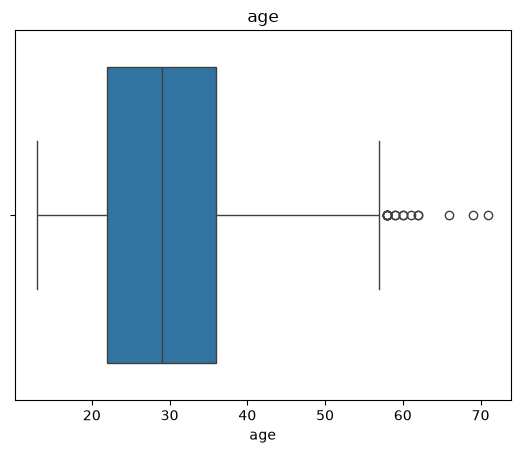

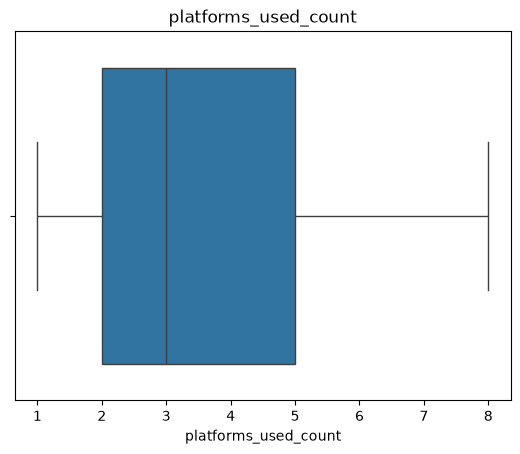

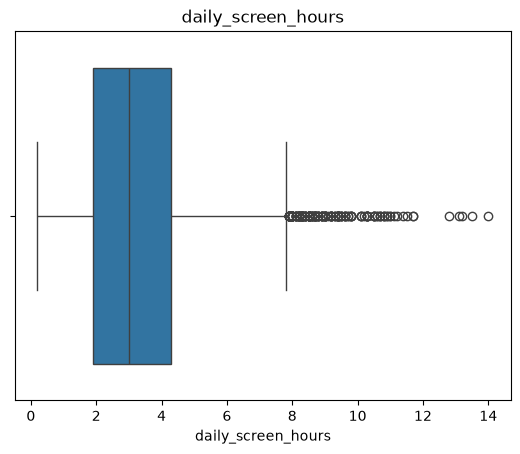

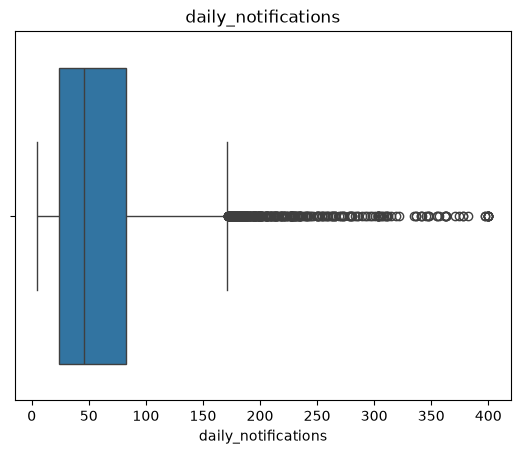

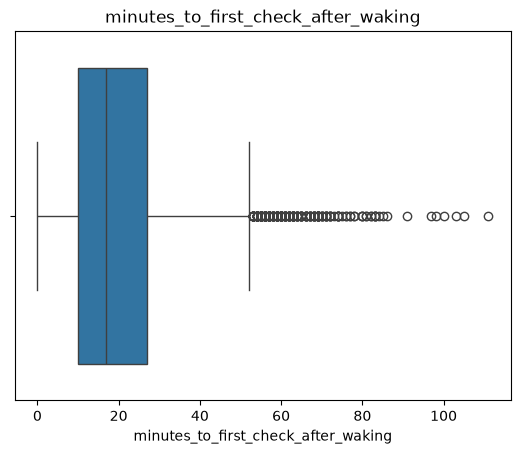

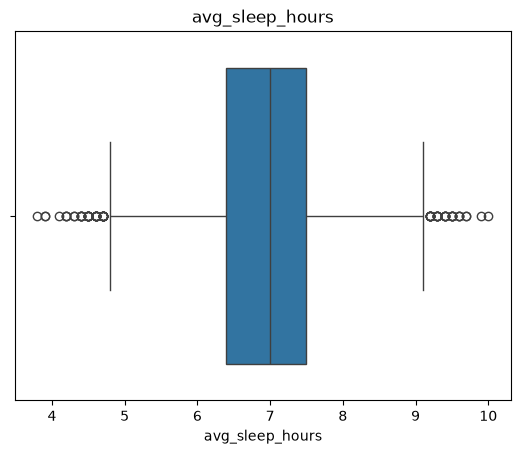

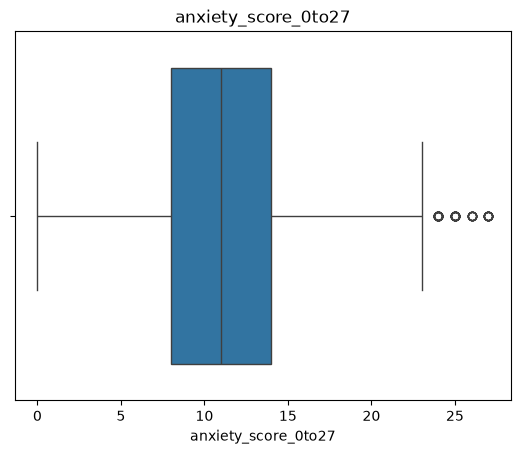

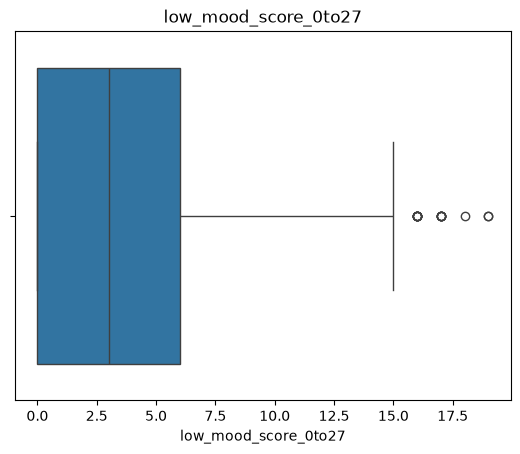

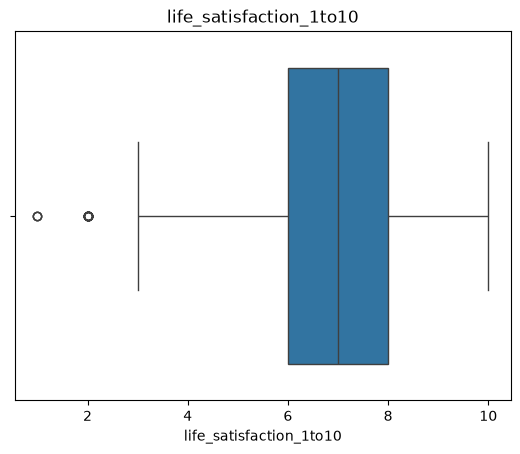

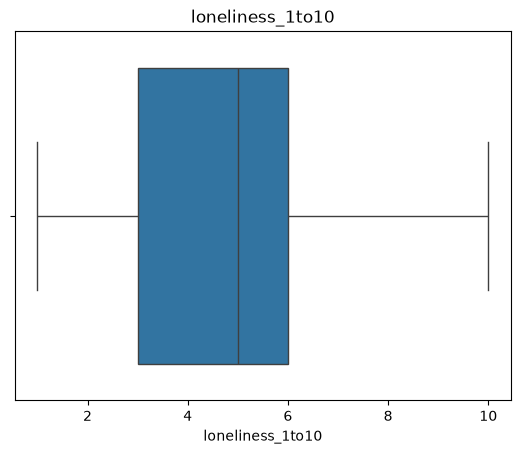

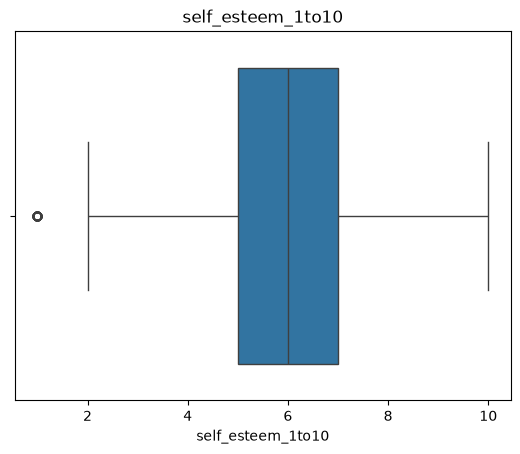

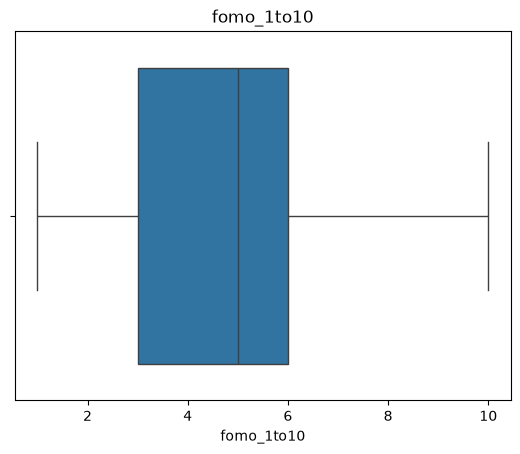

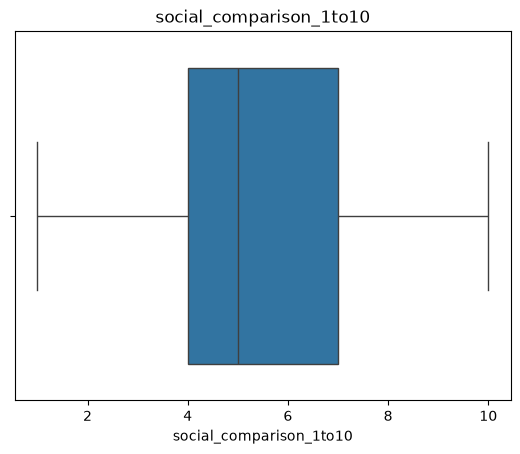

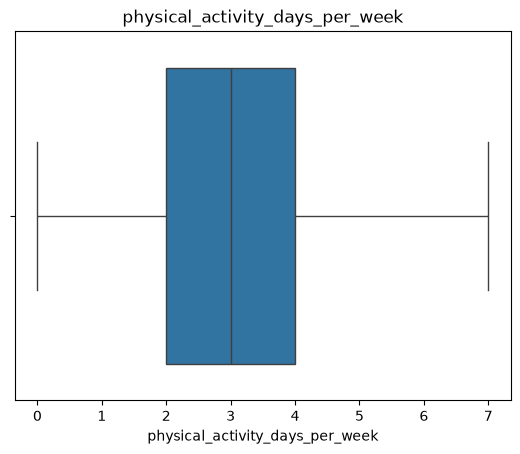

In [13]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [14]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, len(outliers))

age 17
platforms_used_count 0
daily_screen_hours 171
daily_notifications 341
minutes_to_first_check_after_waking 227
avg_sleep_hours 73
anxiety_score_0to27 65
low_mood_score_0to27 17
life_satisfaction_1to10 27
loneliness_1to10 0
self_esteem_1to10 78
fomo_1to10 0
social_comparison_1to10 0
physical_activity_days_per_week 0


In [15]:
df["screen_time_category"] = pd.cut(
    df["daily_screen_hours"],
    bins=[0, 2, 5, 24],
    labels=["Low", "Medium", "High"]
)

In [17]:
df["sleep_category"] = pd.cut(
    df["avg_sleep_hours"],
    bins=[0, 6, 8, 24],
    labels=["Poor", "Normal", "Excellent"]
)

In [18]:
df["screen_per_platform"] = (
    df["daily_screen_hours"] /
    df["platforms_used_count"]
)

In [19]:
df["notifications_per_hour"] = (
    df["daily_notifications"] /
    df["daily_screen_hours"]
)

In [20]:
df["mental_health_score"] = (
    df["anxiety_score_0to27"] +
    df["low_mood_score_0to27"]
)

In [21]:
df["social_media_risk"] = (
    df["daily_screen_hours"] +
    df["fomo_1to10"] +
    df["social_comparison_1to10"]
)

In [22]:
df["wellbeing_score"] = (
    df["life_satisfaction_1to10"] +
    df["self_esteem_1to10"] -
    df["loneliness_1to10"]
)

In [23]:
df["digital_wellness"] = (
    df["avg_sleep_hours"] +
    df["physical_activity_days_per_week"]
)

In [24]:
df["night_use_binary"] = (
    df["night_time_use"] == "Every night"
).astype(int)

In [25]:
df["detox_binary"] = (
    df["attempted_digital_detox"] == "Yes"
).astype(int)

In [26]:
df["screen_limit_binary"] = (
    df["uses_screen_time_limits"] == "Yes"
).astype(int)

In [27]:
df["support_binary"] = (
    df["seeks_mental_health_support"] == "Yes"
).astype(int)

In [28]:
df

,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,minutes_to_first_check_after_waking,...,screen_per_platform,notifications_per_hour,mental_health_score,social_media_risk,wellbeing_score,digital_wellness,night_use_binary,detox_binary,screen_limit_binary,support_binary
0,33,Male,Student,Latin America,TikTok,8,3.2,172,Never,25,...,0.400000,53.750000,17,17.2,7,12.7,0,0,0,0
1,23,Female,Full-time employed,Oceania,Instagram,8,4.5,38,Often,26,...,0.562500,8.444444,20,17.5,10,11.3,0,0,0,1
2,56,Female,Full-time employed,Africa,Instagram,1,5.3,74,Every night,12,...,5.300000,13.962264,18,10.3,4,12.0,1,0,0,0
3,13,Male,Student,Europe,YouTube,4,3.4,49,Sometimes,21,...,0.850000,14.411765,13,9.4,10,11.0,0,0,0,1
4,36,Female,Student,Asia,LinkedIn,5,5.8,227,Never,19,...,1.160000,39.137931,16,21.8,6,9.7,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,30,Male,Part-time employed,Europe,Snapchat,4,3.6,74,Never,7,...,0.900000,20.555556,10,16.6,6,7.9,0,0,1,0
6996,28,Male,Self-employed,North America,Facebook,3,5.0,104,Every night,48,...,1.666667,20.800000,13,18.0,14,6.8,1,0,0,0
6997,26,Prefer not to say,Unemployed,Oceania,LinkedIn,3,1.2,25,Never,6,...,0.400000,20.833333,17,8.2,10,11.6,0,0,0,0
6998,22,Female,Student,Europe,Snapchat,4,3.6,182,Sometimes,12,...,0.900000,50.555556,13,10.6,2,9.3,0,0,0,0


In [29]:
corr = df.corr(numeric_only=True)

In [32]:
df.to_csv("../data/processed/cleaned_data.csv",index = False)